In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df= pd.read_csv('Housing.csv')
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [3]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


## Data Summary
The dataset contains 545 rows and 13 columns with both numerical and categorical features. The target variable is price, 
making this a regression problem. 
Initial inspection shows the dataset is suitable for further analysis.

In [4]:
df.tail(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
535,2100000,3360,2,1,1,yes,no,no,no,no,1,no,unfurnished
536,1960000,3420,5,1,2,no,no,no,no,no,0,no,unfurnished
537,1890000,1700,3,1,2,yes,no,no,no,no,0,no,unfurnished
538,1890000,3649,2,1,1,yes,no,no,no,no,0,no,unfurnished
539,1855000,2990,2,1,1,no,no,no,no,no,1,no,unfurnished
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished
544,1750000,3850,3,1,2,yes,no,no,no,no,0,no,unfurnished


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [6]:
df.dtypes

price               int64
area                int64
bedrooms            int64
bathrooms           int64
stories             int64
mainroad              str
guestroom             str
basement              str
hotwaterheating       str
airconditioning       str
parking             int64
prefarea              str
furnishingstatus      str
dtype: object

In [7]:
df.columns.tolist()

['price',
 'area',
 'bedrooms',
 'bathrooms',
 'stories',
 'mainroad',
 'guestroom',
 'basement',
 'hotwaterheating',
 'airconditioning',
 'parking',
 'prefarea',
 'furnishingstatus']

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
price,545.0,4.766729e+06,1.870440e+06,1750000.0,3430000.0,4340000.0,5740000.0,13300000.0
area,545.0,5.150541e+03,2.170141e+03,1650.0,3600.0,4600.0,6360.0,16200.0
bedrooms,545.0,2.965138e+00,7.380639e-01,1.0,2.0,3.0,3.0,6.0
bathrooms,545.0,1.286239e+00,5.024696e-01,1.0,1.0,1.0,2.0,4.0
stories,545.0,1.805505e+00,8.674925e-01,1.0,1.0,2.0,2.0,4.0
parking,545.0,6.935780e-01,8.615858e-01,0.0,0.0,0.0,1.0,3.0


In [9]:
df.isna().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

## Data Cleaning
The dataset was checked for missing values and duplicate records. 
No missing values or duplicate entries were found, so no additional data cleaning was required

## Exploratory Data Analysis

## Distribution

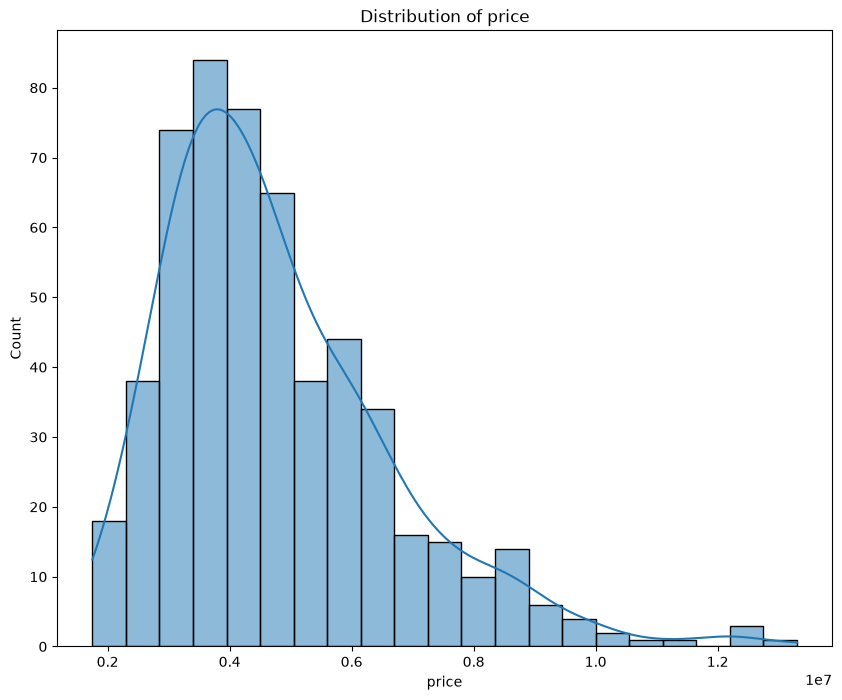

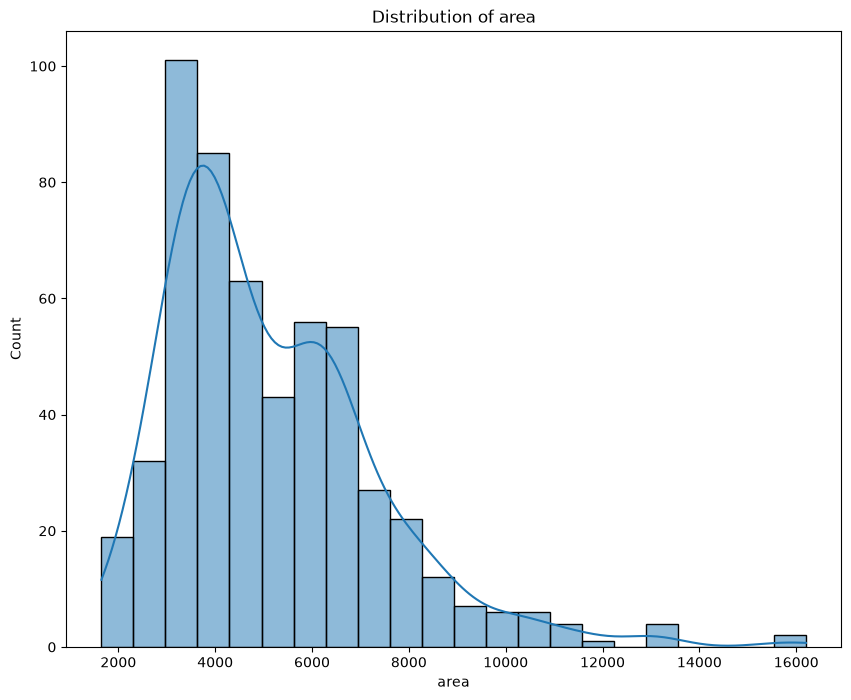

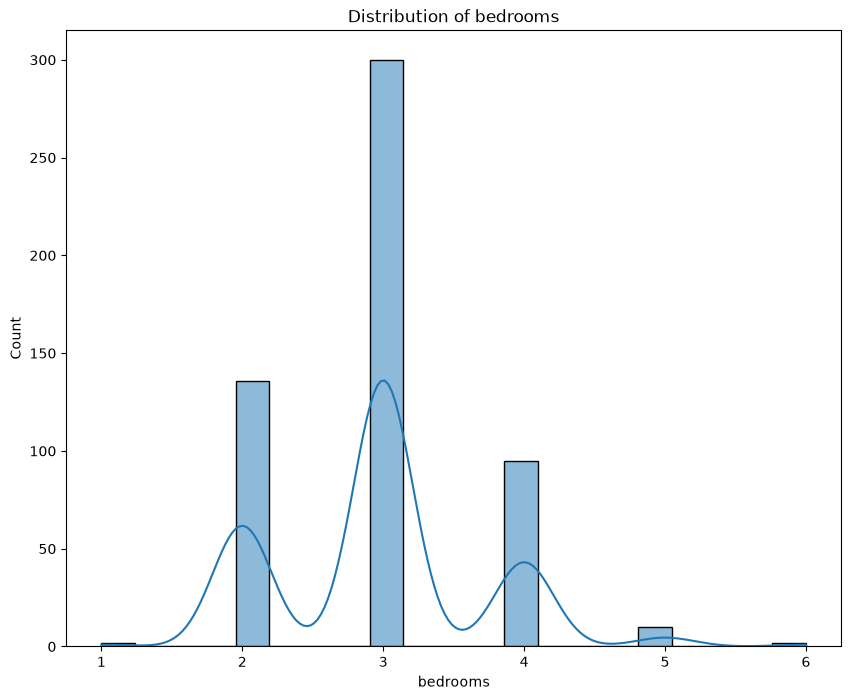

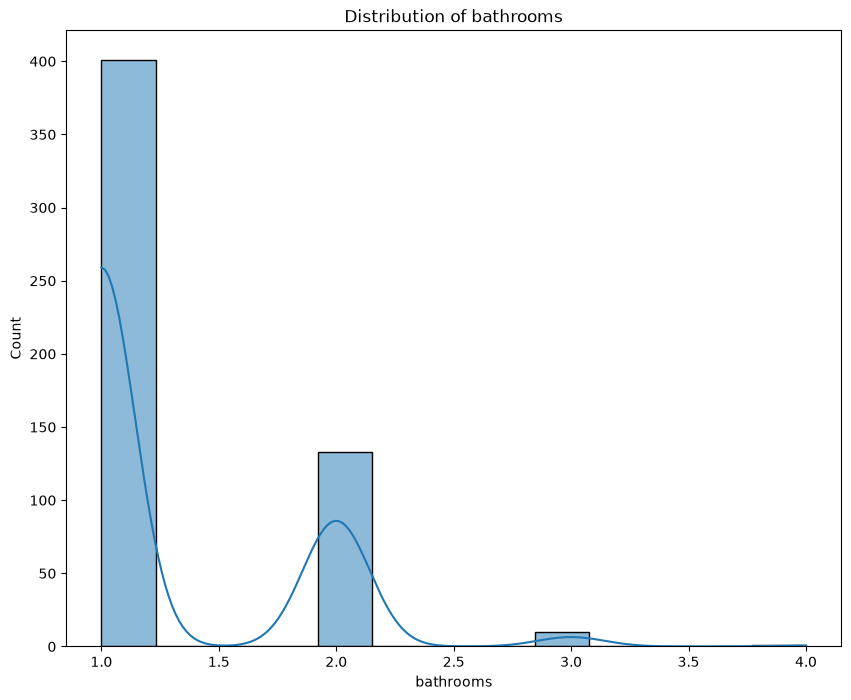

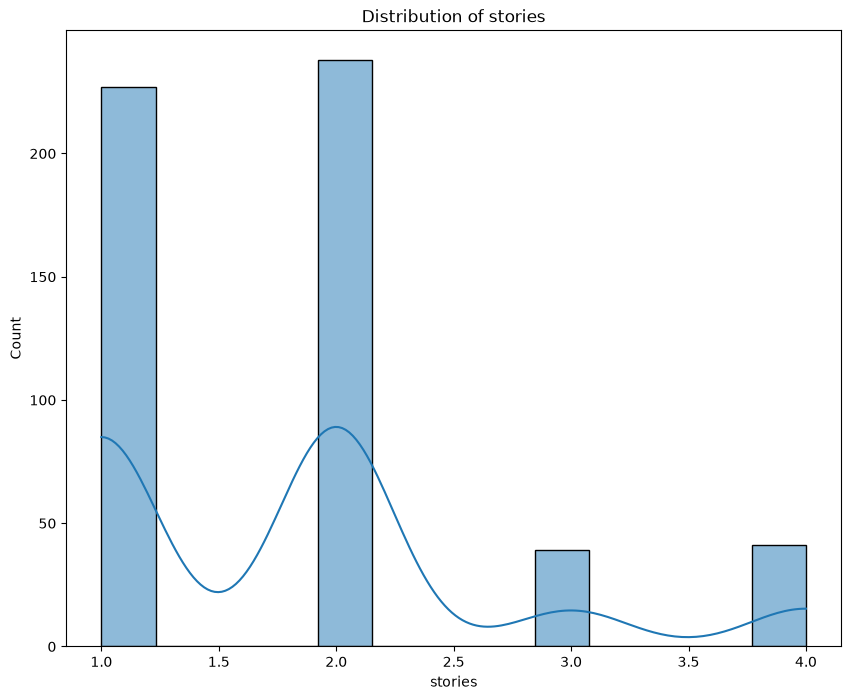

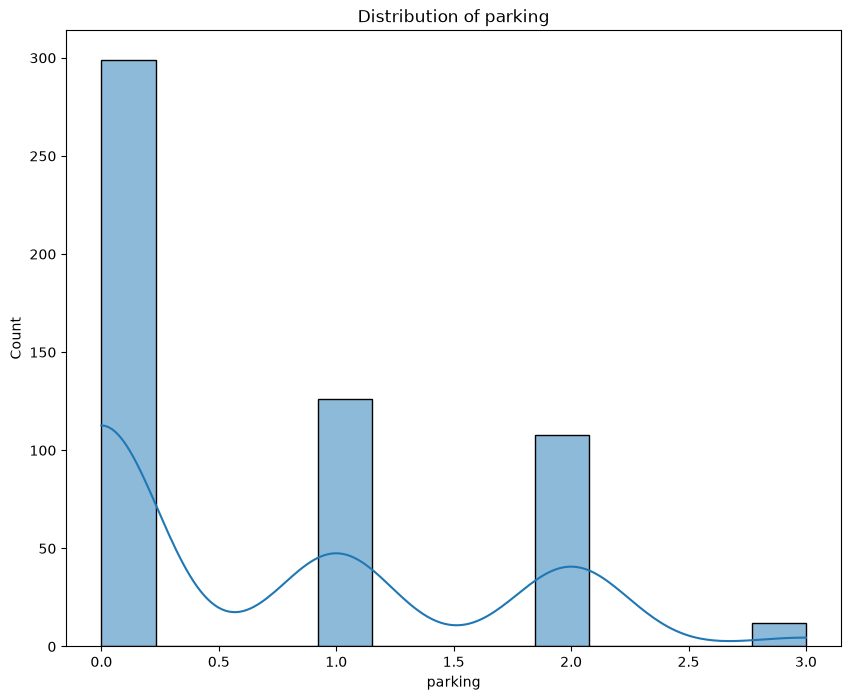

In [11]:
num_col = df.select_dtypes(include=np.number)
for col in num_col:
    plt.figure(figsize=(10,8))
    sns.histplot(df[col],kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

## Detecting Outlier 

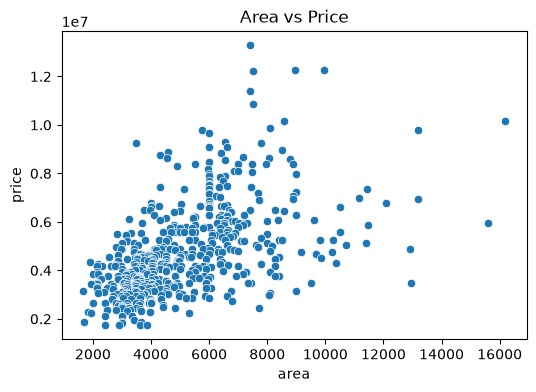

In [12]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="area", y="price", data=df)
plt.title("Area vs Price")
plt.show()

In [13]:
for col in num_col:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1 
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier = df[(df[col] < lower) | (df[col] > upper)]
    print(f'{col}: {len(outlier)} outlier')

price: 15 outlier
area: 12 outlier
bedrooms: 12 outlier
bathrooms: 1 outlier
stories: 41 outlier
parking: 12 outlier


## Outlier Analysis
The IQR method detected outliers in several numerical features. The highest number of outliers was found in stories (41), followed by price (15), area (12), bedrooms (12), parking (12), and bathrooms (1). These values were retained because they likely represent genuine house characteristics rather than data entry errors.

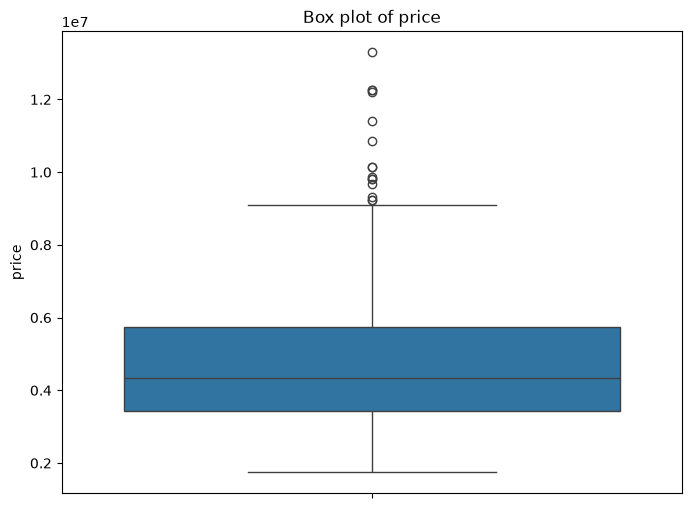

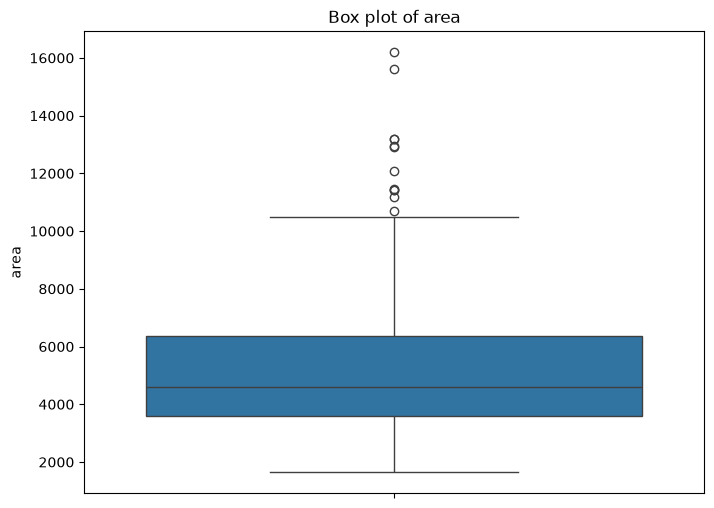

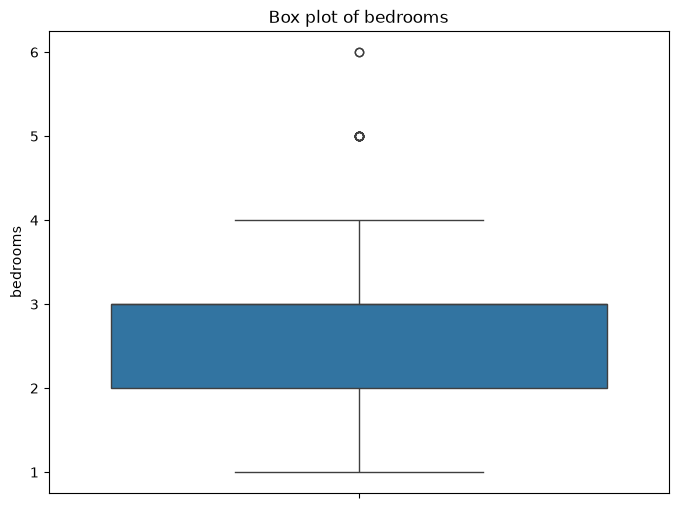

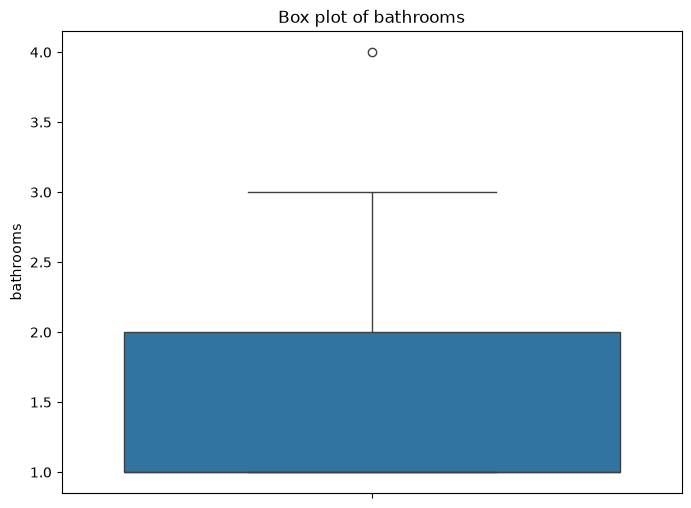

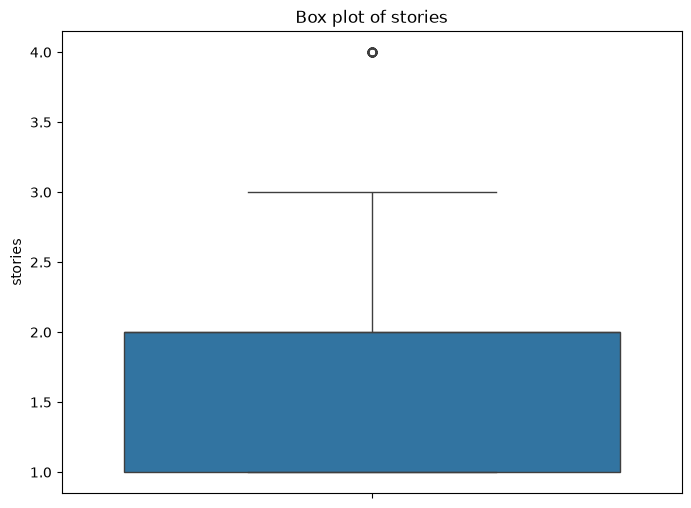

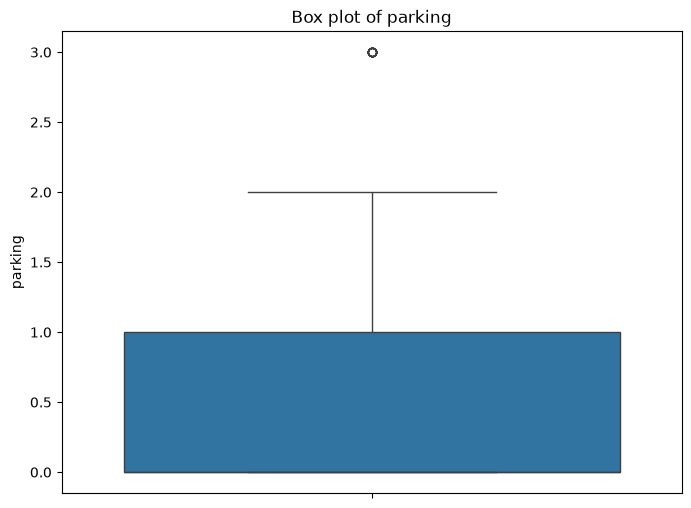

In [14]:
for col in num_col:
    plt.figure(figsize=(8,6))
    sns.boxplot(df[col])
    plt.title(f'Box plot of {col}')
    plt.show()

## Correlation

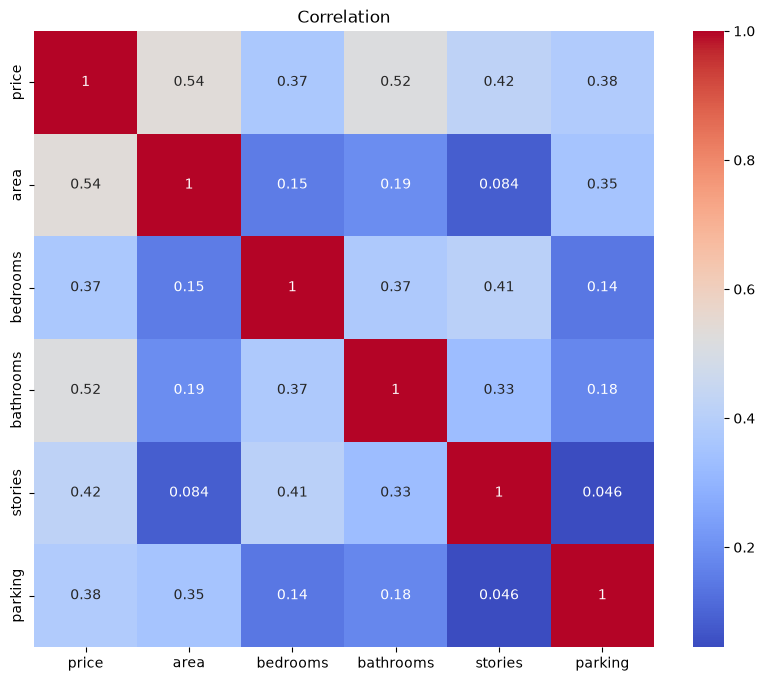

In [15]:
corr_col = num_col.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_col, annot=True, cmap="coolwarm")
plt.title("Correlation")
plt.show()

## Exploratory Data Analysis (EDA)
Exploratory Data Analysis was performed to understand the data distribution, identify outliers, and examine relationships between variables. Outliers were detected in some numerical features, 
and the correlation heatmap helped identify features associated with house prices.

In [16]:
## Encoding categorical value

df = pd.get_dummies(df, drop_first=True, dtype=int)
df.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,12250000,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,12250000,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,12215000,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,11410000,7420,4,1,2,2,1,1,1,0,1,0,0,0


In [23]:
import sklearn.model_selection

In [28]:
## Spliting  into feature and target
from sklearn.model_selection import train_test_split

X= df.drop("price",axis=1)
y= df['price']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2, random_state=42)

## Feature Engineering
During feature engineering, categorical variables were converted into numerical values using One-Hot Encoding. The target variable (price) was separated from the input features, and the dataset was split into training (80%) and testing (20%) sets to prepare the data for regression model building.

#### Linear Regression

In [29]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,y_train)
print(f'test score:{lr.score(X_test,y_test)}')
print(f'train score: {lr.score(X_train,y_train)}')
lr_pred = lr.predict(X_test)
print(lr_pred)

test score:0.6529242642153184
train score: 0.6859438988560158
[5164653.90033967 7224722.29802167 3109863.24240338 4612075.3272256
 3294646.25725956 3532275.09556558 5611774.56836476 6368145.98732718
 2722856.95689985 2629405.61585782 9617039.5031558  2798087.30447888
 3171096.76847063 3394639.09125528 3681088.65424275 5263187.74621485
 3035963.47612384 4786122.8004005  4349551.9200572  3572362.09930452
 5774875.21395649 5886993.57919884 2730836.19518458 4727316.47323635
 5244847.527168   7555324.21605603 3220790.84680268 5191898.79934207
 8143726.91009785 3398814.09825035 6490693.05027925 3315105.9074781
 6708457.36761326 4201738.21071676 3557571.06735186 5836974.50478626
 4808660.67448475 4362878.73613261 3191242.95701508 4596554.93225238
 4566042.86048411 3517779.52374148 7205844.79365835 3983597.27861103
 3749338.70271056 4274731.09125895 6757442.10783741 4037320.43665851
 3769334.90397126 3417627.44377156 7268416.67644611 2802534.35431384
 4341750.61420452 4516422.15345642 3679997.

# Ridge Regression

In [30]:
from sklearn.linear_model import Ridge
rdg = Ridge(alpha=1.0)
rdg.fit(X_train,y_train)
print(f'train score: {rdg.score(X_train,y_train)}')
print(f'test score: {rdg.score(X_test, y_test)}')
rdg_pred = rdg.predict(X_test)
print(f'prediction: {rdg_pred}')

train score: 0.6859056084302118
test score: 0.6524978002155007
prediction: [5173868.36838042 7203148.05775089 3112871.3919437  4611232.01352973
 3296685.59765397 3542015.80334188 5612900.74084453 6355730.50511459
 2732161.29565314 2635358.80212032 9598373.567282   2801415.59177403
 3169533.04663026 3407364.55698659 3689875.45659858 5251809.30829526
 3038524.17011303 4788755.24308945 4362434.46559573 3577750.92600674
 5770084.24505369 5877773.3807341  2733818.31258629 4728789.89190736
 5261790.37986332 7553879.07480567 3223012.41145781 5182519.36379551
 8144442.26630276 3398689.32685122 6468307.87476827 3324316.57154058
 6694319.92025871 4212932.88566115 3570008.16748537 5825256.02693722
 4821006.63971783 4363658.07853622 3192416.18162936 4590026.81210597
 4580489.58795061 3510662.2039062  7184173.38289117 3989770.75911903
 3755638.50281658 4272165.00130827 6749672.66137261 4050956.90943398
 3777662.61330642 3423801.67684183 7266512.17270572 2806540.41258067
 4347201.47806353 4520771.74

## Laso Reggression

In [31]:
from sklearn.linear_model import Lasso
lasso = Lasso(alpha=1.0)
lasso.fit(X_train,y_train)
print(f'test score: {lasso.score(X_test,y_test)}')
print(f'train score: {lasso.score(X_train,y_train)}')
lasso_pred =lasso.predict(X_test)
print(lasso_pred)

test score: 0.6529237537036754
train score: 0.6859438988357532
[5164663.86568962 7224711.19182057 3109868.36024848 4612077.89400339
 3294641.56426558 3532281.79521881 5611771.29284505 6368130.57873106
 2722862.64796812 2629406.37543599 9617037.55685736 2798091.5384084
 3171103.60807079 3394650.1802658  3681093.09386814 5263187.99296155
 3035967.34073665 4786125.89821041 4349558.6273859  3572369.37658247
 5774874.85740655 5886987.95543083 2730840.11511493 4727311.93962505
 5244857.04431059 7555329.21412006 3220789.11086667 5191885.96893062
 8143725.39364943 3398809.94567152 6490687.0897499  3315109.83157733
 6708445.06201536 4201746.5561567  3557576.01468333 5836973.79318459
 4808662.2034099  4362877.70228495 3191248.92843902 4596546.30339932
 4566052.10829524 3517779.42340502 7205833.59931714 3983594.04078866
 3749346.80630211 4274733.67178261 6757444.73095859 4037326.19879402
 3769343.67270979 3417630.81693435 7268420.55034191 2802537.75561807
 4341750.91905004 4516430.78558545 368000

## Evaluate Models

In [32]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

def evaluate(actual, predicted):
    print("R² Score :", r2_score(actual, predicted))
    print("MAE      :", mean_absolute_error(actual, predicted))
    print("RMSE     :", np.sqrt(mean_squared_error(actual, predicted)))

## Linear Regression

In [33]:
print("Linear Regression")
evaluate(y_test, lr_pred)

Linear Regression
R² Score : 0.6529242642153184
MAE      : 970043.403920164
RMSE     : 1324506.9600914388


## Ridge Regression

In [34]:
print("Ridge Regression")
evaluate(y_test, rdg_pred)

Ridge Regression
R² Score : 0.6524978002155007
MAE      : 970245.6821765782
RMSE     : 1325320.444109758


In [35]:
print("lasso Regression")
evaluate(y_test, lasso_pred)

lasso Regression
R² Score : 0.6529237537036754
MAE      : 970043.8327936052
RMSE     : 1324507.9341957998


## Model Comparison

In [36]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression", "Lasso Regression"],
    "R2 Score": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, rdg_pred),
        r2_score(y_test, lasso_pred)
    ],
    "MAE": [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, rdg_pred),
        mean_absolute_error(y_test, lasso_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, rdg_pred)),
        np.sqrt(mean_squared_error(y_test, lasso_pred))
    ]
})

comparison

,Model,R2 Score,MAE,RMSE
0,Linear Regression,0.652924,970043.403920,1.324507e+06
1,Ridge Regression,0.652498,970245.682177,1.325320e+06
2,Lasso Regression,0.652924,970043.832794,1.324508e+06


In [37]:
comparison.sort_values("R2 Score", ascending=False)

,Model,R2 Score,MAE,RMSE
0,Linear Regression,0.652924,970043.403920,1.324507e+06
2,Lasso Regression,0.652924,970043.832794,1.324508e+06
1,Ridge Regression,0.652498,970245.682177,1.325320e+06


In [38]:
print("Linear:", lr.score(X_test, y_test))
print("Ridge :", rdg.score(X_test, y_test))
print("Lasso :", lasso.score(X_test, y_test))

Linear: 0.6529242642153184
Ridge : 0.6524978002155007
Lasso : 0.6529237537036754


In [39]:
print(np.allclose(lr_pred, rdg_pred))
print(np.allclose(lr_pred, lasso_pred))

False
True


## Conclusion
This project successfully developed and evaluated three regression models—Linear Regression, Ridge Regression, and Lasso Regression—to predict house prices. After preprocessing the data and encoding categorical variables, the models were evaluated using R² Score, MAE, and RMSE. Linear Regression achieved the best performance with an R² score of approximately 0.653, while Ridge and Lasso Regression produced very similar results, indicating that regularization had minimal impact on this dataset. Overall, the project demonstrates that linear regression techniques can effectively predict house prices using the available housing features.

In [40]:
import joblib

In [41]:
#Export Lasso Model
joblib.dump(lasso,'housing_model.pkl')

['housing_model.pkl']